In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HUGGING_FACE_TOKEN")

In [3]:
import os
os.environ["HF_TOKEN"] = secret_value_0

In [4]:
ds = load_dataset("helloerikaaa/cbis-ddsm-r", split="train")
df = ds.to_pandas()
print(f"  Loaded {len(df)} rows, {len(df.columns)} columns.")

README.md: 0.00B [00:00, ?B/s]

cbis-ddsm-r-dataset.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2437 [00:00<?, ? examples/s]

  Loaded 2437 rows, 110 columns.


In [5]:
df.columns

Index(['patient_id', 'breast_density', 'breast_laterality', 'image_view',
       'abnormality_id', 'abnormality_type', 'calc_type', 'calc_dist',
       'mass_shape', 'mass_margins',
       ...
       'original_glszm_SmallAreaLowGrayLevelEmphasis',
       'original_glszm_ZoneEntropy', 'original_glszm_ZonePercentage',
       'original_glszm_ZoneVariance', 'original_ngtdm_Busyness',
       'original_ngtdm_Coarseness', 'original_ngtdm_Complexity',
       'original_ngtdm_Contrast', 'original_ngtdm_Strength', 'has_four_views'],
      dtype='object', length=110)

In [6]:
df['pathology'].value_counts()

pathology
MALIGNANT                  1064
BENIGN                     1019
BENIGN_WITHOUT_CALLBACK     354
Name: count, dtype: int64

In [7]:
df["label"] = (df["pathology"] == "MALIGNANT").astype(int)

In [8]:
df['label'].value_counts()

label
0    1373
1    1064
Name: count, dtype: int64

In [9]:
RADIOMICS_PREFIXES = [
    "original_firstorder_",
    "original_glcm_",
    "original_gldm_",
    "original_glrlm_",
    "original_glszm_",
    "original_ngtdm_",
]
radiomics_cols = [
    c for c in df.columns
    if any(c.startswith(p) for p in RADIOMICS_PREFIXES)
]

In [10]:
other_features = [
    c for c in df.columns
    if c not in radiomics_cols
]

In [12]:
other_features

['patient_id',
 'breast_density',
 'breast_laterality',
 'image_view',
 'abnormality_id',
 'abnormality_type',
 'calc_type',
 'calc_dist',
 'mass_shape',
 'mass_margins',
 'assessment',
 'pathology',
 'subtlety',
 'image_file_path',
 'ROI_mask_file_path',
 'cropped_image_file_path',
 'has_four_views',
 'label']

In [13]:
CLINICAL_FEATURES = [
    "breast_density", "assessment", "subtlety",
    "breast_laterality", "image_view", "abnormality_type",
]
clinical_cols = [
    c for c in CLINICAL_FEATURES if c in df.columns
]

In [14]:
len(radiomics_cols)

93

In [15]:
clinical_cat_cols = df[clinical_cols].select_dtypes(include="object").columns.tolist()
df = pd.get_dummies(df, columns=clinical_cat_cols, drop_first=True)

### Baseline (Radiomics Only)

In [20]:
df[radiomics_cols] = df[radiomics_cols].fillna(
        df[radiomics_cols].median()
)

In [21]:
X = df[radiomics_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1949, 93), Test: (488, 93)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    eval_metric="auc", random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [24]:
svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

In [25]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

In [26]:
def evaluate(y_true, y_pred, y_proba, name):
    return {
        "model": name,
        "AUC": roc_auc_score(y_true, y_proba),
        "F1": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_xgb, y_proba_xgb, "XGBoost"),
    evaluate(y_test, y_pred_svm, y_proba_svm, "SVM"),
    evaluate(y_test, y_pred_lr, y_proba_lr, "Logistic Regression"),
])
results

,model,AUC,F1,Accuracy
0,XGBoost,0.706615,0.564232,0.645492
1,SVM,0.676859,0.584071,0.614754
2,Logistic Regression,0.653299,0.543326,0.600410


In [27]:
print(classification_report(y_test, y_pred_xgb, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.67      0.74      0.70       275
   Malignant       0.61      0.53      0.56       213

    accuracy                           0.65       488
   macro avg       0.64      0.63      0.63       488
weighted avg       0.64      0.65      0.64       488



### Feature Selection (LASSO, RFE-LR)

In [28]:
lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)

lasso_selector = SelectFromModel(lasso_cv, prefit=True)
lasso_cols = [radiomics_cols[i] for i in range(len(radiomics_cols))
              if lasso_selector.get_support()[i]]
print(f"LASSO selected: {len(lasso_cols)} features")
print(lasso_cols)

LASSO selected: 47 features
['original_firstorder_10Percentile', 'original_firstorder_Energy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_RootMeanSquared', 'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity', 'original_glcm_DifferenceVariance', 'original_glcm_Idmn', 'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_MCC', 'original_gldm_DependenceNonUniformity', 'original_gldm_DependenceNonUniformityNormalized', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glrlm_GrayLevelNonUniformity', 'original_glrlm_GrayLevelNonUniformityNormalized', 'original_glrlm_GrayLevelVariance', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_glrlm_LongRunLowGrayLevelEmphasis', 'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity', 'original_glrlm_RunLength

In [29]:
import time

K = 20 # No of features to select
rfe = RFE(
    estimator=LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    n_features_to_select=K,
    step=5,      # eliminate 5 features per iteration (faster)
    verbose=0
)
t0 = time.time()
rfe.fit(X_train_scaled, y_train)
print(f"RFE done in {time.time()-t0:.1f}s")

rfe_cols = [radiomics_cols[i] for i in rfe.get_support(indices=True)]
print(f"RFE selected: {len(rfe_cols)} features")
print(rfe_cols)

RFE done in 1.1s
RFE selected: 20 features
['original_firstorder_Entropy', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_RootMeanSquared', 'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity', 'original_glcm_DifferenceEntropy', 'original_glcm_Id', 'original_glcm_Imc1', 'original_glcm_InverseVariance', 'original_glcm_JointEntropy', 'original_glcm_MCC', 'original_glcm_SumEntropy', 'original_gldm_DependenceVariance', 'original_gldm_SmallDependenceEmphasis', 'original_gldm_SmallDependenceHighGrayLevelEmphasis', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glszm_HighGrayLevelZoneEmphasis', 'original_glszm_ZoneEntropy', 'original_ngtdm_Coarseness']


In [30]:
all_methods = {
    "LASSO":    set(lasso_cols),
    "RFE-LR":   set(rfe_cols),
}

# Build presence matrix
all_features = sorted(set().union(*all_methods.values()))
presence_df = pd.DataFrame(
    {method: [1 if f in feats else 0 for f in all_features]
     for method, feats in all_methods.items()},
    index=all_features
)
presence_df["votes"] = presence_df.sum(axis=1)
presence_df = presence_df.sort_values("votes", ascending=False)
presence_df

,LASSO,RFE-LR,votes
original_firstorder_RootMeanSquared,1,1,2
original_firstorder_Uniformity,1,1,2
original_firstorder_TotalEnergy,1,1,2
original_glcm_MCC,1,1,2
original_glcm_InverseVariance,1,1,2
original_glszm_HighGrayLevelZoneEmphasis,1,1,2
original_glrlm_HighGrayLevelRunEmphasis,1,1,2
original_glszm_ZoneEntropy,1,1,2
original_firstorder_Mean,0,1,1
original_firstorder_Entropy,0,1,1


In [31]:
consensus_cols = list(presence_df[presence_df["votes"] == 2].index)
print(f"Features selected by ALL 2 methods: {len(consensus_cols)}")
print(consensus_cols)

Features selected by ALL 2 methods: 8
['original_firstorder_RootMeanSquared', 'original_firstorder_Uniformity', 'original_firstorder_TotalEnergy', 'original_glcm_MCC', 'original_glcm_InverseVariance', 'original_glszm_HighGrayLevelZoneEmphasis', 'original_glrlm_HighGrayLevelRunEmphasis', 'original_glszm_ZoneEntropy']


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_xgb(cols, label):
    idx = [radiomics_cols.index(c) for c in cols]
    X_sub = X_train[:, idx]   # raw unscaled for XGBoost
    res = cross_validate(
        XGBClassifier(n_estimators=200, max_depth=4,
                      learning_rate=0.05, eval_metric="auc", random_state=42),
        X_sub, y_train,
        cv=skf, scoring=["roc_auc", "f1", "accuracy"], n_jobs=-1
    )
    return {
        "Method": label,
        "N Features": len(cols),
        "AUC":      f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        "F1":       f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
        "Accuracy": f"{res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}",
    }

fs_results = pd.DataFrame([
    cv_xgb(lasso_cols,    "LASSO"),
    cv_xgb(rfe_cols,      "RFE-LR"),
    cv_xgb(consensus_cols,   "Consensus (2 votes)"),
    cv_xgb(radiomics_cols,"All 93 features (baseline)"),
])
fs_results

,Method,N Features,AUC,F1,Accuracy
0,LASSO,47,0.7131 ± 0.0185,0.5601 ± 0.0135,0.6455 ± 0.0119
1,RFE-LR,20,0.7014 ± 0.0123,0.5729 ± 0.0261,0.6583 ± 0.0121
2,Consensus (2 votes),8,0.6973 ± 0.0059,0.5562 ± 0.0187,0.6444 ± 0.0091
3,All 93 features (baseline),93,0.6993 ± 0.0129,0.5689 ± 0.0328,0.6526 ± 0.0253


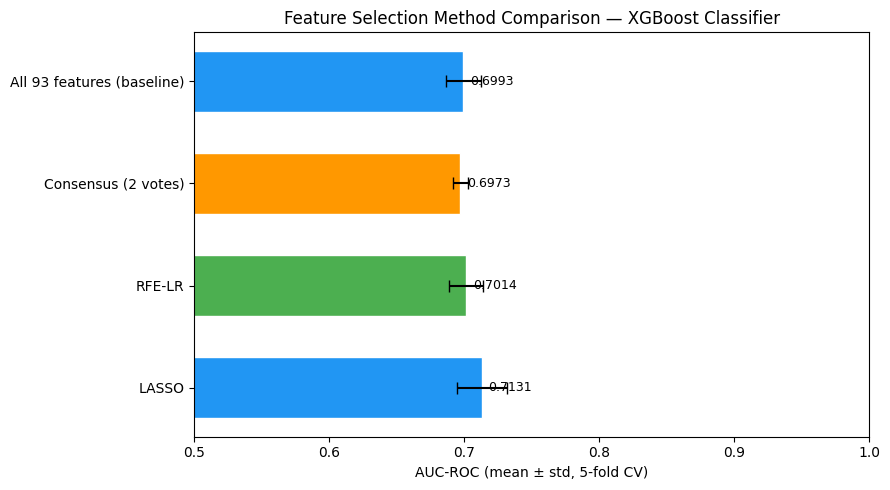

In [34]:
import matplotlib.pyplot as plt

# Extract just the mean AUC for plotting
auc_means = [float(r.split(" ±")[0]) for r in fs_results["AUC"]]
auc_stds  = [float(r.split("± ")[1]) for r in fs_results["AUC"]]

plt.figure(figsize=(9, 5))
bars = plt.barh(fs_results["Method"], auc_means, xerr=auc_stds,
                color=["#2196F3","#4CAF50","#FF9800"],
                capsize=4, edgecolor="white", height=0.6)
plt.xlabel("AUC-ROC (mean ± std, 5-fold CV)")
plt.title("Feature Selection Method Comparison — XGBoost Classifier")
plt.xlim(0.5, 1.0)
for bar, val in zip(bars, auc_means):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
# Identify best method by AUC mean
best_idx    = auc_means.index(max(auc_means))
best_method = fs_results["Method"].iloc[best_idx]
print(f"Best feature selection method: {best_method}")
print(f"Best AUC: {fs_results['AUC'].iloc[best_idx]}")

# Save the winning feature column list for phase 3
method_cols = {
    "LASSO":                 lasso_cols,
    "RFE-LR":                rfe_cols,
    "Consensus (2 votes)":  consensus_cols,
    "All 93 features (baseline)": radiomics_cols,
}
best_cols = method_cols[best_method]
print(f"\nCarrying {len(best_cols)} features into phase 3: {best_cols[:5]} ...")

Best feature selection method: LASSO
Best AUC: 0.7131 ± 0.0185

Carrying 47 features into phase 3: ['original_firstorder_10Percentile', 'original_firstorder_Energy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum'] ...


### Deep learning features

Using csv from huggingface: helloerikaaa/cbis-ddsm-r and images from kaggle: awsaf49/cbis-ddsm-breast-cancer-image-dataset

In [38]:
img_data = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"

# Load dicom_info — this is the key bridge file
dicom_info = pd.read_csv(f"{img_data}/csv/dicom_info.csv")
print(dicom_info.shape)
print(dicom_info["SeriesDescription"].value_counts())
dicom_info.head()

(10237, 38)
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [39]:
cropped = dicom_info[dicom_info["SeriesDescription"] == "cropped images"].copy()
cropped["image_path"].head()

0     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
3     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
6     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
7     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
10    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
Name: image_path, dtype: object

In [40]:
# Check HuggingFace image path structure
print("HF CSV sample paths:")
print(df["cropped_image_file_path"].head(3).values)

# Check Kaggle dicom_info cropped image paths  
cropped = dicom_info[dicom_info["SeriesDescription"] == "cropped images"]
print("\nKaggle dicom_info sample paths:")
print(cropped["image_path"].head(3).values)

HF CSV sample paths:
['Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.67512362210319636108148504382680781938/1.3.6.1.4.1.9590.100.1.2.296281207812130400303493285473798422894/000001.dcm\n'
 'Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.241202057913673145232234613012384759880/1.3.6.1.4.1.9590.100.1.2.314135871111943890422150247820137952041/000001.dcm\n'
 'Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.314250272911170289203882349024229868823/1.3.6.1.4.1.9590.100.1.2.91458279612485515203413781822560852485/000001.dcm\n']

Kaggle dicom_info sample paths:
['CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg'
 'CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317/1-052.jpg'
 'CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/1-034.jpg']


In [41]:
def extract_uid2_from_hf(path):
    # CaseName/UID1/UID2/000001.dcm  →  UID2 is index 2
    parts = str(path).strip().split("/")
    return parts[2] if len(parts) > 2 else None

df["uid2"] = df["cropped_image_file_path"].apply(extract_uid2_from_hf)

print(f"UID1 extracted: {df['uid2'].notna().sum()} / {len(df)}")
print("\nSample UID2s:")
df["uid2"].head(3).values

UID1 extracted: 2437 / 2437

Sample UID2s:


array(['1.3.6.1.4.1.9590.100.1.2.296281207812130400303493285473798422894',
       '1.3.6.1.4.1.9590.100.1.2.314135871111943890422150247820137952041',
       '1.3.6.1.4.1.9590.100.1.2.91458279612485515203413781822560852485'],
      dtype=object)

In [42]:
cropped = dicom_info[dicom_info["SeriesDescription"] == "cropped images"].copy()

def extract_uid1_from_kaggle(path):
    # CBIS-DDSM/jpeg/UID1/1-034.jpg  →  UID1 is index 2
    parts = str(path).strip().split("/")
    return parts[2] if len(parts) > 2 else None

cropped["uid1"] = cropped["image_path"].apply(extract_uid1_from_kaggle)

print(f"Cropped image entries: {len(cropped)}")
print(f"Unique UID1s in Kaggle: {cropped['uid1'].nunique()}")
print("\nSample UID1s:")
cropped["uid1"].head(3).values

Cropped image entries: 3567
Unique UID1s in Kaggle: 3567

Sample UID1s:


array(['1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304',
       '1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317',
       '1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138'],
      dtype=object)

In [43]:
print("Cropped images in huggingface dataset:")
print(df["cropped_image_file_path"].count())

print("\nTotal dicom_info SeriesDescription counts:")
print(dicom_info["SeriesDescription"].value_counts())

Cropped images in huggingface dataset:
2437

Total dicom_info SeriesDescription counts:
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


In [44]:
hf_uids     = set(df["uid2"].dropna())
kaggle_uids = set(cropped["uid1"].dropna())

print(f"HF UID1s:               {len(hf_uids)}")
print(f"Kaggle UID1s:           {len(kaggle_uids)}")
print(f"Overlap: {len(hf_uids & kaggle_uids)}")
print(f"HF UIDs missing from Kaggle: {len(hf_uids - kaggle_uids)}")

HF UID1s:               2437
Kaggle UID1s:           3567
Overlap: 2437
HF UIDs missing from Kaggle: 0


In [45]:
def fix_image_path(path):
    return str(path).strip().replace(
        "CBIS-DDSM/jpeg",
        f"{img_data}/jpeg"
    )

cropped["local_path"] = cropped["image_path"].apply(fix_image_path)

image_map = cropped.set_index("uid1")["local_path"].to_dict()

print(f"Image map size: {len(image_map)}")
print("\nSample entry:")
sample_uid = list(image_map.keys())[0]

print(f"  UID1: {sample_uid}")
print(f"  Path: {image_map[sample_uid]}")

Image map size: 3567

Sample entry:
  UID1: 1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304
  Path: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg


In [46]:
df["img_path"] = df["uid2"].map(image_map)

matched   = df["img_path"].notna().sum()
unmatched = df["img_path"].isna().sum()

print(f"Matched:   {matched} / {len(df)}")
print(f"Unmatched: {unmatched} / {len(df)}")

Matched:   2437 / 2437
Unmatched: 0 / 2437


In [47]:
df_matched = df[df["img_path"].notna()].reset_index(drop=True)

print(f"Final dataset: {len(df_matched)} rows")
print(f"  Malignant: {df_matched['label'].sum()}")
print(f"  Benign:    {(1 - df_matched['label']).sum()}")

Final dataset: 2437 rows
  Malignant: 1064
  Benign:    1373


In [48]:
def extract_case_id(path):
    if pd.isna(path):
        return None
    # Everything before the first "/"
    return str(path).strip().split("/")[0]

df_matched["case_id"] = df_matched["cropped_image_file_path"].apply(extract_case_id)
print(f"Matched: {df_matched['case_id'].notna().sum()} / {len(df_matched)}")
print("\nSample case IDs:")
df_matched["case_id"].head(10).values

Matched: 2437 / 2437

Sample case IDs:


array(['Calc-Training_P_00005_RIGHT_MLO_1',
       'Calc-Training_P_00007_LEFT_CC_1',
       'Calc-Training_P_00007_LEFT_MLO_1',
       'Calc-Training_P_00008_LEFT_CC_1',
       'Calc-Training_P_00008_LEFT_MLO_1',
       'Calc-Training_P_00008_RIGHT_CC_1',
       'Calc-Training_P_00008_RIGHT_MLO_1',
       'Calc-Training_P_00010_LEFT_CC_1',
       'Calc-Training_P_00010_LEFT_MLO_1',
       'Calc-Training_P_00011_LEFT_CC_1'], dtype=object)

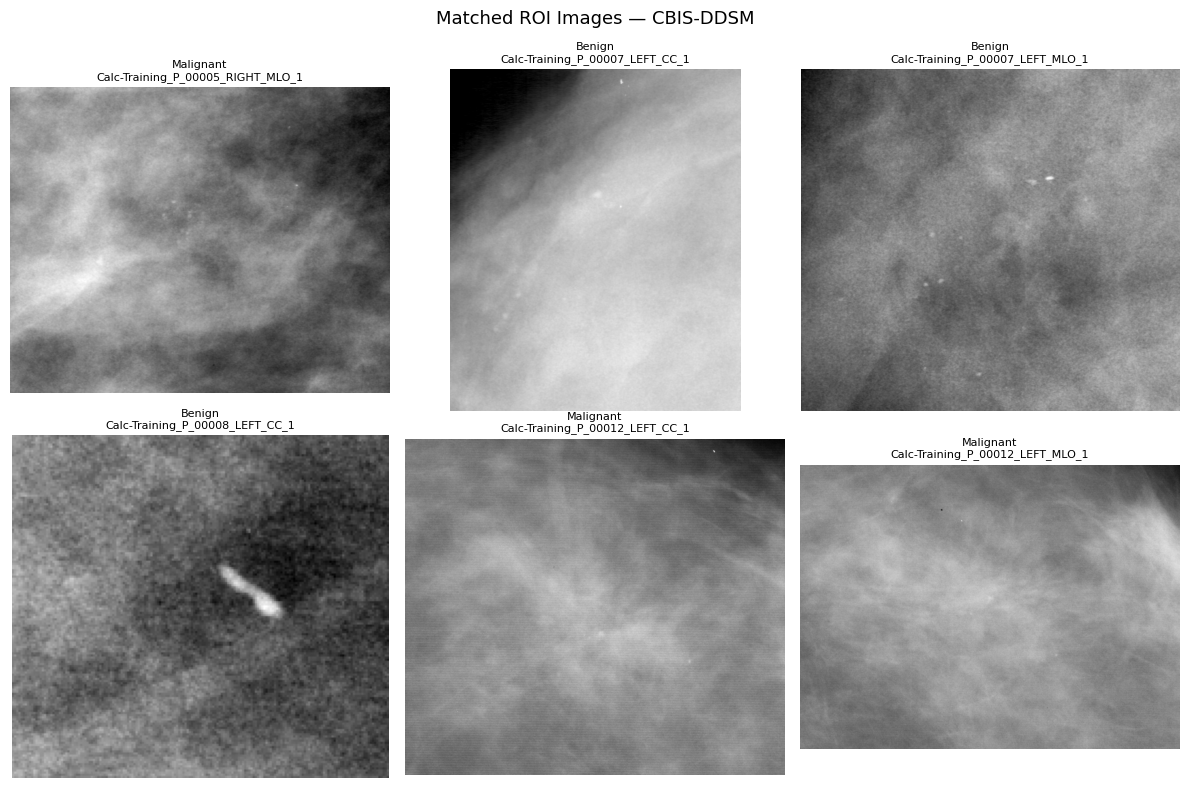

In [49]:
from PIL import Image

samples = df_matched.groupby("label").head(3).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row["img_path"]).convert("L")
    ax.imshow(img, cmap="gray")
    label_name = "Malignant" if row["label"] == 1 else "Benign"
    ax.set_title(f"{label_name}\n{row['case_id'][:35]}", fontsize=8)
    ax.axis("off")

plt.suptitle("Matched ROI Images — CBIS-DDSM", fontsize=13)
plt.tight_layout()
plt.show()

In [50]:
!pip install -q timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.4 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

#### Pytorch Dataset

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CBISDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["img_path"]).convert("RGB")
        label = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

dataset = CBISDataset(df_matched, transform=transform)
loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

# Sanity check
imgs, labels = next(iter(loader))
print(f"Batch shape: {imgs.shape}")
print(f"Labels:      {labels[:8]}")

Batch shape: torch.Size([32, 3, 224, 224])
Labels:      tensor([1, 0, 0, 0, 0, 0, 0, 0])


In [52]:
import timm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# num_classes=0 removes the classification head → outputs feature vector
resnet = timm.create_model("resnet50", pretrained=True,
                            num_classes=0, global_pool="avg")
resnet.eval().to(device)

for p in resnet.parameters():
    p.requires_grad = False

# Confirm output feature dimension
with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224).to(device)
    out   = resnet(dummy)
print(f"ResNet50 feature dim: {out.shape[1]}")   # expect 2048

Device: cuda


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet50 feature dim: 2048


In [53]:
from tqdm.notebook import tqdm
all_feats, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Extracting ResNet50 features"):
        feats = resnet(imgs.to(device))
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

deep_features = np.concatenate(all_feats,  axis=0)
deep_labels   = np.concatenate(all_labels, axis=0)

print(f"Deep features shape: {deep_features.shape}")   # (2437, 2048)
print(f"Labels shape:        {deep_labels.shape}")
print(f"Label distribution:  {np.bincount(deep_labels)}")

Extracting ResNet50 features:   0%|          | 0/77 [00:00<?, ?it/s]

Deep features shape: (2437, 2048)
Labels shape:        (2437,)
Label distribution:  [1373 1064]


In [54]:
# Get radiomics features
X_rad = df_matched[best_cols].fillna(df_matched[best_cols].median()).values
y     = df_matched["label"].values

print(f"Radiomics matrix: {X_rad.shape}")    # (2437, 47)
print(f"Deep features:    {deep_features.shape}")  # (2437, 2048)
print(f"Labels match:     {np.array_equal(y, deep_labels)}")

Radiomics matrix: (2437, 47)
Deep features:    (2437, 2048)
Labels match:     True


In [55]:
# Scale radiomics (deep features from pretrained model are already well-scaled)
from sklearn.preprocessing import StandardScaler

scaler_rad    = StandardScaler()
X_rad_scaled  = scaler_rad.fit_transform(X_rad)

# Concatenate: (2437, 47) + (2437, 2048) = (2437, 2095)
X_fused = np.concatenate([X_rad_scaled, deep_features], axis=1)

print(f"Fused feature matrix: {X_fused.shape}")

Fused feature matrix: (2437, 2095)


In [56]:
from sklearn.model_selection import train_test_split

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fused, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Also keep separate splits for individual arms
X_train_rad, X_test_rad = X_train_f[:, :47],  X_test_f[:, :47]
X_train_deep, X_test_deep = X_train_f[:, 47:], X_test_f[:, 47:]

print(f"Train: {X_train_f.shape}, Test: {X_test_f.shape}")

Train: (1949, 2095), Test: (488, 2095)


In [57]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(X, y, label):
    clf = XGBClassifier(n_estimators=200, max_depth=4,
                        learning_rate=0.05, eval_metric="auc",
                        random_state=42, n_jobs=-1)
    res = cross_validate(clf, X, y, cv=skf,
                         scoring=["roc_auc", "f1", "accuracy"],
                         n_jobs=-1)
    return {
        "Arm":      label,
        "AUC":      f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        "F1":       f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
        "Accuracy": f"{res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}",
    }

results_arms = pd.DataFrame([
    cv_score(X_train_rad,   y_train_f, "Radiomics only (47 features)"),
    cv_score(X_train_deep,  y_train_f, "ResNet50 only (2048 features)"),
    cv_score(X_train_f,     y_train_f, "Fusion: Radiomics + ResNet50"),
])
results_arms

,Arm,AUC,F1,Accuracy
0,Radiomics only (47 features),0.7115 ± 0.0165,0.5628 ± 0.0152,0.6475 ± 0.0146
1,ResNet50 only (2048 features),0.7184 ± 0.0160,0.5795 ± 0.0101,0.6639 ± 0.0161
2,Fusion: Radiomics + ResNet50,0.7504 ± 0.0114,0.5949 ± 0.0261,0.6788 ± 0.0186


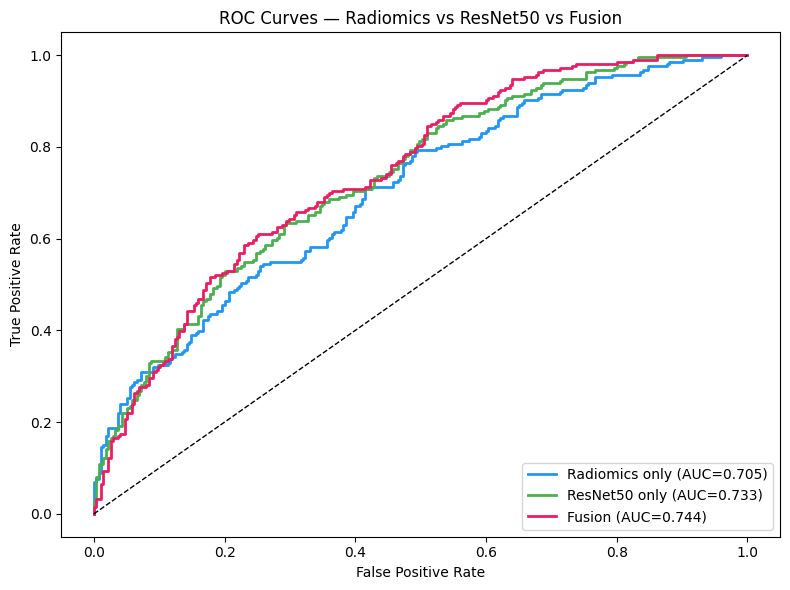

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["#2196F3", "#4CAF50", "#E91E63"]

for (X_tr, X_te, label, color) in [
    (X_train_rad,   X_test_rad,   "Radiomics only",        colors[0]),
    (X_train_deep,  X_test_deep,  "ResNet50 only",         colors[1]),
    (X_train_f,     X_test_f,     "Fusion",                colors[2]),
]:
    clf = XGBClassifier(n_estimators=200, max_depth=4,
                        learning_rate=0.05, eval_metric="auc",
                        random_state=42)
    clf.fit(X_tr, y_train_f)
    proba       = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_f, proba)
    auc         = roc_auc_score(y_test_f, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{label} (AUC={auc:.3f})")

ax.plot([0,1],[0,1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Radiomics vs ResNet50 vs Fusion")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_phase3.png", dpi=150)
plt.show()

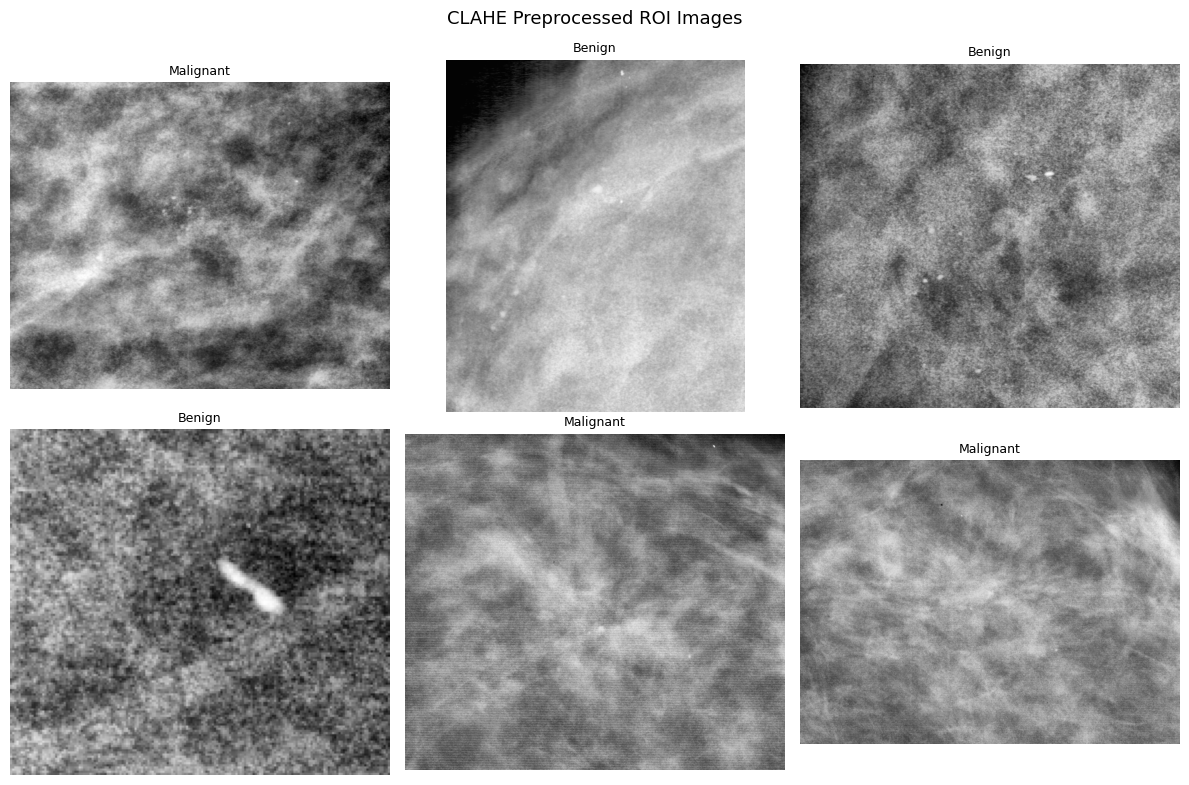

In [74]:
import cv2

class CBISDatasetCLAHE(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def apply_clahe(self, img_path):
        img  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return Image.fromarray(np.zeros((224, 224), dtype=np.uint8)).convert("RGB")
        # Apply CLAHE
        clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_cl   = clahe.apply(img)
        img_rgb  = cv2.cvtColor(img_cl, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = self.apply_clahe(row["img_path"])
        label = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Show CLAHE effect on a sample
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples   = df_matched.groupby("label").head(3).reset_index(drop=True)
ds_viz    = CBISDatasetCLAHE(samples)

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = ds_viz.apply_clahe(row["img_path"])
    ax.imshow(img, cmap="gray")
    ax.set_title("Malignant" if row["label"] == 1 else "Benign", fontsize=9)
    ax.axis("off")
plt.suptitle("CLAHE Preprocessed ROI Images", fontsize=13)
plt.tight_layout()
plt.show()

In [70]:
# scale_pos_weight = n_negative / n_positive
n_neg = (df_matched["label"] == 0).sum()
n_pos = (df_matched["label"] == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Benign (0):    {n_neg}")
print(f"Malignant (1): {n_pos}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Benign (0):    1373
Malignant (1): 1064
scale_pos_weight: 1.290


In [61]:
import timm
from tqdm.notebook import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

def extract_features(model_name, df, transform, batch_size=32):
    """
    Load pretrained model, freeze all weights,
    extract features for all images in df.
    Returns (features, labels) as numpy arrays.
    """
    print(f"\nExtracting features: {model_name}")

    # Load model with head removed
    model = timm.create_model(model_name, pretrained=True,
                               num_classes=0, global_pool="avg")
    model.eval().to(device)
    for p in model.parameters():
        p.requires_grad = False

    # Confirm feature dim
    with torch.no_grad():
        dummy = torch.zeros(1, 3, 224, 224).to(device)
        dim   = model(dummy).shape[1]
    print(f"  Feature dim: {dim}")

    dataset = CBISDatasetCLAHE(df, transform=transform)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2)

    all_feats, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {model_name}"):
            feats = model(imgs.to(device))
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    feats  = np.concatenate(all_feats,  axis=0)
    labels = np.concatenate(all_labels, axis=0)
    print(f"  Done: {feats.shape}")

    # Free GPU memory
    del model
    torch.cuda.empty_cache()
    return feats, labels

Device: cuda


In [62]:
# This cell takes ~5-10 mins on Kaggle T4 — all three models back to back
cnn_features = {}

for model_name in ["resnet50", "densenet121", "tf_efficientnetv2_s"]:
    feats, labels = extract_features(model_name, df_matched, transform)
    cnn_features[model_name] = {"feats": feats, "labels": labels}

print("\nAll CNN features extracted.")


Extracting features: resnet50
  Feature dim: 2048


  resnet50:   0%|          | 0/77 [00:00<?, ?it/s]

  Done: (2437, 2048)

Extracting features: densenet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

  Feature dim: 1024


...

  Done: (2437, 1024)

Extracting features: tf_efficientnetv2_s


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

  Feature dim: 1280


  tf_efficientnetv2_s:   0%|          | 0/77 [00:00<?, ?it/s]

  Done: (2437, 1280)

All CNN features extracted.


In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_xgb_imbalanced(X, y, label):
    clf = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,   # class imbalance fix
        eval_metric="auc", random_state=42, n_jobs=-1
    )
    res = cross_validate(clf, X, y, cv=skf,
                         scoring=["roc_auc", "f1", "accuracy"],
                         n_jobs=-1)
    return {
        "Model":    label,
        "AUC":      f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        "F1":       f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
        "Accuracy": f"{res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}",
    }

cnn_results = pd.DataFrame([
    cv_xgb_imbalanced(cnn_features["resnet50"]["feats"],
                      cnn_features["resnet50"]["labels"],       "ResNet50 (frozen)"),
    cv_xgb_imbalanced(cnn_features["densenet121"]["feats"],
                      cnn_features["densenet121"]["labels"],    "DenseNet121 (frozen)"),
    cv_xgb_imbalanced(cnn_features["tf_efficientnetv2_s"]["feats"],
                      cnn_features["tf_efficientnetv2_s"]["labels"], "EfficientNetV2-S (frozen)"),
])
cnn_results

,Model,AUC,F1,Accuracy
0,ResNet50 (frozen),0.7332 ± 0.0202,0.5970 ± 0.0175,0.6602 ± 0.0135
1,DenseNet121 (frozen),0.7555 ± 0.0105,0.6279 ± 0.0243,0.6857 ± 0.0179
2,EfficientNetV2-S (frozen),0.6820 ± 0.0198,0.5562 ± 0.0432,0.6274 ± 0.0188


In [64]:
# Extract mean AUC for each model and pick winner
cnn_results["AUC_mean"] = cnn_results["AUC"].apply(
    lambda x: float(x.split(" ±")[0])
)
best_cnn_name = cnn_results.loc[cnn_results["AUC_mean"].idxmax(), "Model"]
best_cnn_key  = cnn_results.loc[cnn_results["AUC_mean"].idxmax(), "Model"].split(" ")[0].lower()

print(f"Best CNN: {best_cnn_name}")
print(f"Best AUC: {cnn_results['AUC'].iloc[cnn_results['AUC_mean'].idxmax()]}")

# Map display name back to timm model string
model_name_map = {
    "resnet50":          "resnet50",
    "densenet121":       "densenet121",
    "efficientnetv2-s":  "tf_efficientnetv2_s",
}
# Get best features for fine-tuning
best_frozen_feats  = cnn_features[
    [k for k in cnn_features if best_cnn_name.lower().startswith(k.split("_")[0])][0]
]["feats"]

Best CNN: DenseNet121 (frozen)
Best AUC: 0.7555 ± 0.0105


In [65]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split

# Map best CNN to timm string
timm_name_map = {
    "resnet50":       "resnet50",
    "densenet121":    "densenet121",
    "efficientnetv2": "tf_efficientnetv2_s",
}
timm_name = next(v for k, v in timm_name_map.items()
                 if k in best_cnn_name.lower())

print(f"Fine-tuning: {timm_name}")

# Load model WITH classification head for fine-tuning
finetune_model = timm.create_model(timm_name, pretrained=True,
                                    num_classes=2)
finetune_model.to(device)

# Freeze all layers first
for p in finetune_model.parameters():
    p.requires_grad = False

# Unfreeze only last block + classifier head
# Works for ResNet50, DenseNet121, EfficientNet
def unfreeze_last_layers(model, model_name):
    if "resnet" in model_name:
        for p in model.layer4.parameters():
            p.requires_grad = True
    elif "densenet" in model_name:
        for p in model.features.denseblock4.parameters():
            p.requires_grad = True
    elif "efficientnet" in model_name:
        # Unfreeze last 2 blocks
        blocks = list(model.blocks.children())
        for block in blocks[-2:]:
            for p in block.parameters():
                p.requires_grad = True
    # Always unfreeze classifier head
    for p in model.get_classifier().parameters():
        p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

unfreeze_last_layers(finetune_model, timm_name)

Fine-tuning: densenet121
  Trainable params: 2,160,130 / 6,955,906 (31.1%)


In [82]:
inputs, targets = next(iter(train_loader))

print("Inputs shape:", inputs.shape)    # Output: torch.Size([4, 3])
print("Targets shape:", targets.shape)  # Output: torch.Size([4])

Inputs shape: torch.Size([16, 3, 224, 224])
Targets shape: torch.Size([16])


In [84]:
# Train/val split for fine-tuning
train_df, val_df = train_test_split(
    df_matched, test_size=0.15, stratify=df_matched["label"], random_state=42
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(
    CBISDatasetCLAHE(train_df, transform=train_transform),
    batch_size=16, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    CBISDatasetCLAHE(val_df, transform=transform),
    batch_size=16, shuffle=False, num_workers=2
)

# Class-weighted loss
pos_weight  = torch.tensor([scale_pos_weight]).to(device)
criterion   = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, scale_pos_weight]).float().to(device)
)
optimizer   = AdamW(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler   = CosineAnnealingLR(optimizer, T_max=15)

EPOCHS       = 15
best_val_auc = 0
best_weights = None
history      = {"train_loss": [], "val_auc": []}

print("Fine-tuning started...")
for epoch in range(EPOCHS):
    # ── Train ──
    finetune_model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = finetune_model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()

    # ── Validate ──
    finetune_model.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            logits = finetune_model(imgs.to(device))
            probs  = torch.softmax(logits, dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(labels.numpy())

    val_auc = roc_auc_score(val_true, val_probs)
    history["train_loss"].append(train_loss / len(train_loader))
    history["val_auc"].append(val_auc)

    print(f"  Epoch {epoch+1:02d}/{EPOCHS} — "
          f"loss: {train_loss/len(train_loader):.4f}  val_auc: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_weights = {k: v.clone() for k, v in finetune_model.state_dict().items()}

print(f"\nBest val AUC: {best_val_auc:.4f}")
finetune_model.load_state_dict(best_weights)

Fine-tuning started...
  Epoch 01/15 — loss: 0.6680  val_auc: 0.6634
  Epoch 02/15 — loss: 0.6120  val_auc: 0.6936
  Epoch 03/15 — loss: 0.5892  val_auc: 0.7135
  Epoch 04/15 — loss: 0.5839  val_auc: 0.7162
  Epoch 05/15 — loss: 0.5805  val_auc: 0.7214
  Epoch 06/15 — loss: 0.5519  val_auc: 0.7361
  Epoch 07/15 — loss: 0.5498  val_auc: 0.7279
  Epoch 08/15 — loss: 0.5455  val_auc: 0.7421
  Epoch 09/15 — loss: 0.5376  val_auc: 0.7427
  Epoch 10/15 — loss: 0.5271  val_auc: 0.7442
  Epoch 11/15 — loss: 0.5192  val_auc: 0.7484
  Epoch 12/15 — loss: 0.5213  val_auc: 0.7524
  Epoch 13/15 — loss: 0.5219  val_auc: 0.7608
  Epoch 14/15 — loss: 0.5141  val_auc: 0.7603
  Epoch 15/15 — loss: 0.5165  val_auc: 0.7570

Best val AUC: 0.7608


<All keys matched successfully>

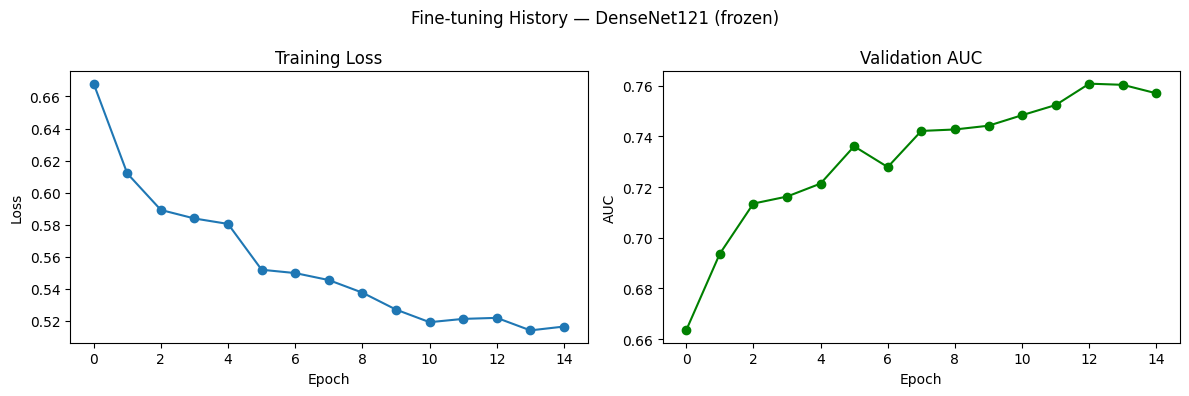

In [85]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], marker="o")
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax2.plot(history["val_auc"], marker="o", color="green")
ax2.set_title("Validation AUC"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUC")
plt.suptitle(f"Fine-tuning History — {best_cnn_name}")
plt.tight_layout()
plt.savefig("finetune_history.png", dpi=150)
plt.show()

In [86]:
# Remove classifier head to get feature vectors
finetune_model.reset_classifier(0)
finetune_model.eval()

ft_feats, ft_labels = [], []
full_loader = DataLoader(
    CBISDatasetCLAHE(df_matched, transform=transform),
    batch_size=32, shuffle=False, num_workers=2
)

with torch.no_grad():
    for imgs, labels in tqdm(full_loader, desc="Extracting fine-tuned features"):
        feats = finetune_model(imgs.to(device))
        ft_feats.append(feats.cpu().numpy())
        ft_labels.append(labels.numpy())

ft_features = np.concatenate(ft_feats,  axis=0)
ft_labels   = np.concatenate(ft_labels, axis=0)
print(f"Fine-tuned features shape: {ft_features.shape}")

del finetune_model
torch.cuda.empty_cache()

Extracting fine-tuned features:   0%|          | 0/77 [00:00<?, ?it/s]

Fine-tuned features shape: (2437, 1024)


In [87]:
vit_features = {}

for model_name in ["swin_tiny_patch4_window7_224", "deit_small_patch16_224"]:
    feats, labels = extract_features(model_name, df_matched, transform)
    short_name    = "swin_t" if "swin" in model_name else "deit_small"
    vit_features[short_name] = {"feats": feats, "labels": labels}

print("ViT features extracted.")


Extracting features: swin_tiny_patch4_window7_224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Feature dim: 768


  swin_tiny_patch4_window7_224:   0%|          | 0/77 [00:00<?, ?it/s]

  Done: (2437, 768)

Extracting features: deit_small_patch16_224


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  Feature dim: 384


  deit_small_patch16_224:   0%|          | 0/77 [00:00<?, ?it/s]

  Done: (2437, 384)
ViT features extracted.


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_rad_scaled = scaler.fit_transform(X_rad)   # X_rad from cell 47

def make_fused(deep_feats):
    return np.concatenate([X_rad_scaled, deep_feats], axis=1)

fused_features = {
    "resnet50_fusion":      make_fused(cnn_features["resnet50"]["feats"]),
    "densenet121_fusion":   make_fused(cnn_features["densenet121"]["feats"]),
    "efficientnet_fusion":  make_fused(cnn_features["tf_efficientnetv2_s"]["feats"]),
    "finetuned_fusion":     make_fused(ft_features),
    "swin_t_fusion":        make_fused(vit_features["swin_t"]["feats"]),
    "deit_small_fusion":    make_fused(vit_features["deit_small"]["feats"]),
}

print("Fused feature matrices:")
for k, v in fused_features.items():
    print(f"  {k}: {v.shape}")

Fused feature matrices:
  resnet50_fusion: (2437, 2095)
  densenet121_fusion: (2437, 1071)
  efficientnet_fusion: (2437, 1327)
  finetuned_fusion: (2437, 1071)
  swin_t_fusion: (2437, 815)
  deit_small_fusion: (2437, 431)


In [89]:
y = df_matched["label"].values

all_results = []

# Individual frozen CNNs
for key, data in cnn_features.items():
    all_results.append(cv_xgb_imbalanced(data["feats"], data["labels"],
                                          f"{key} (frozen)"))

# Fine-tuned CNN
all_results.append(cv_xgb_imbalanced(ft_features, ft_labels,
                                      f"{best_cnn_name} (fine-tuned)"))

# ViTs
for key, data in vit_features.items():
    all_results.append(cv_xgb_imbalanced(data["feats"], data["labels"],
                                          f"{key} (frozen)"))

# Radiomics only
all_results.append(cv_xgb_imbalanced(X_rad_scaled, y, "Radiomics only"))

# Fused arms
for key, feats in fused_features.items():
    all_results.append(cv_xgb_imbalanced(feats, y, key))

final_df = pd.DataFrame(all_results)
final_df["AUC_mean"] = final_df["AUC"].apply(lambda x: float(x.split(" ±")[0]))
final_df = final_df.sort_values("AUC_mean", ascending=False).drop(columns="AUC_mean")
final_df.reset_index(drop=True)

,Model,AUC,F1,Accuracy
0,finetuned_fusion,0.8200 ± 0.0061,0.7012 ± 0.0048,0.7435 ± 0.0089
1,DenseNet121 (frozen) (fine-tuned),0.8144 ± 0.0097,0.6943 ± 0.0127,0.7366 ± 0.0130
2,densenet121_fusion,0.7668 ± 0.0121,0.6385 ± 0.0267,0.6939 ± 0.0141
3,densenet121 (frozen),0.7555 ± 0.0105,0.6279 ± 0.0243,0.6857 ± 0.0179
4,swin_t_fusion,0.7516 ± 0.0226,0.6342 ± 0.0260,0.6849 ± 0.0144
5,deit_small_fusion,0.7470 ± 0.0269,0.6234 ± 0.0394,0.6746 ± 0.0268
6,resnet50_fusion,0.7452 ± 0.0198,0.6176 ± 0.0348,0.6775 ± 0.0235
7,swin_t (frozen),0.7382 ± 0.0201,0.6159 ± 0.0266,0.6738 ± 0.0151
8,resnet50 (frozen),0.7332 ± 0.0202,0.5970 ± 0.0175,0.6602 ± 0.0135
9,deit_small (frozen),0.7321 ± 0.0212,0.6208 ± 0.0334,0.6726 ± 0.0185
